In [17]:
# Step 1: Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

#Load the Diabetes Dataset

diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="Disease_Progression")

print("Dataset loaded successfully")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Dataset loaded successfully
Features shape: (442, 10)
Target shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [18]:
#Understand the Dataset

print("Feature Names:")
print(diabetes.feature_names)

print("\nDataset Description:")
print(diabetes.DESCR[:1000])

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Dataset Description:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum trigly

In [19]:
#Check for Missing Values

print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing values in target:
0


In [20]:
#Statistical Summary of Dataset

X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [21]:
#  Correlation Analysis

df = X.copy()
df["Disease_Progression"] = y

correlation = df.corr()["Disease_Progression"].sort_values(ascending=False)

print("Correlation of features with disease progression:")
print(correlation)

Correlation of features with disease progression:
Disease_Progression    1.000000
bmi                    0.586450
s5                     0.565883
bp                     0.441482
s4                     0.430453
s6                     0.382483
s1                     0.212022
age                    0.187889
s2                     0.174054
sex                    0.043062
s3                    -0.394789
Name: Disease_Progression, dtype: float64


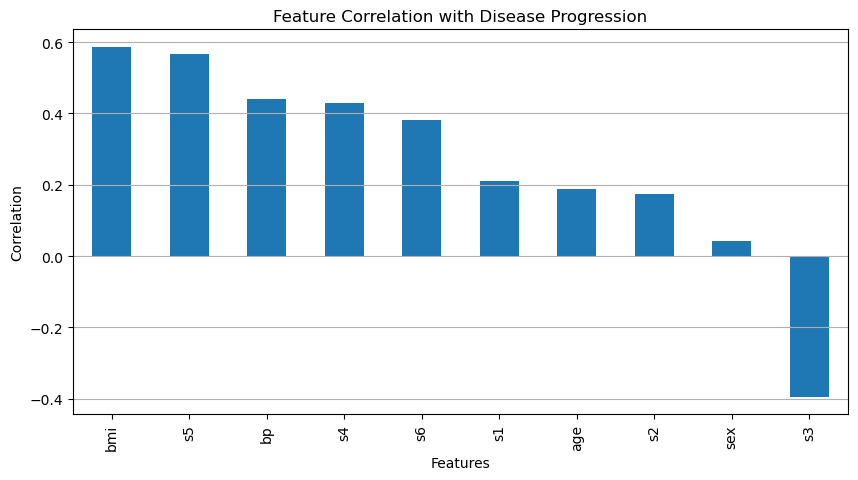

In [22]:
#Visualize Feature Correlation

plt.figure(figsize=(10, 5))
correlation.drop("Disease_Progression").plot(kind="bar")
plt.title("Feature Correlation with Disease Progression")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.grid(axis="y")
plt.show()

In [23]:
# Split Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (353, 10)
Testing data shape: (89, 10)


In [24]:
# Create a Function to Evaluate Models

results = []

def evaluate_model(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)

    mae = mean_absolute_error(y_test_data, y_pred)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(model_name)
    print("MAE:", round(mae, 4))
    print("MSE:", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("R2 Score:", round(r2, 4))

    return y_pred

In [25]:
#Step-2 :Simple Linear Regression

X_simple = X[["bmi"]]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train_simple)

y_pred_simple = evaluate_model(
    "Simple Linear Regression using BMI",
    simple_lr,
    X_test_simple,
    y_test_simple
)

Simple Linear Regression using BMI
MAE: 52.26
MSE: 4061.8259
RMSE: 63.7325
R2 Score: 0.2334


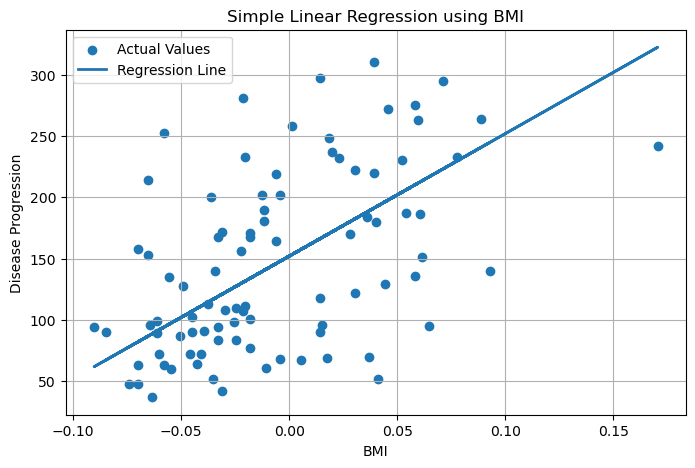

In [27]:
# Visualize Simple Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test_simple, label="Actual Values")
plt.plot(X_test_simple, y_pred_simple, linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression using BMI")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
#Step 3 :  Multiple Linear Regression
multiple_lr = LinearRegression()
multiple_lr.fit(X_train, y_train)

y_pred_multiple = evaluate_model(
    "Multiple Linear Regression",
    multiple_lr,
    X_test,
    y_test
)


Multiple Linear Regression
MAE: 42.7941
MSE: 2900.1936
RMSE: 53.8534
R2 Score: 0.4526


In [29]:
#Display Multiple Linear Regression Coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multiple_lr.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

coefficients


,Feature,Coefficient
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
6,s3,163.419983
9,s6,48.670657
0,age,37.904021
1,sex,-241.964362
4,s1,-931.488846


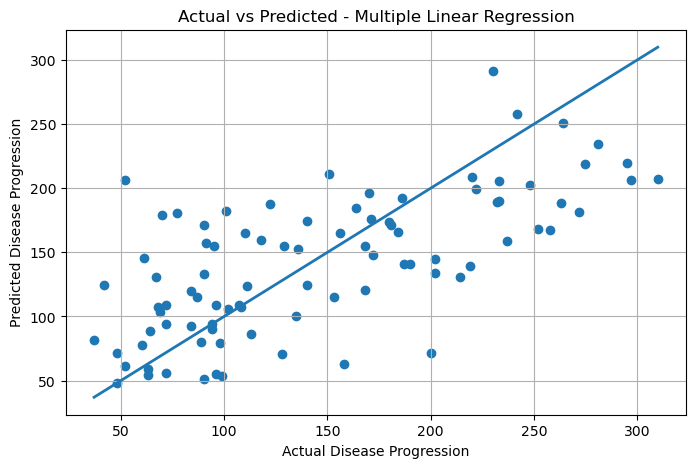

In [30]:
#Visualize Actual vs Predicted Values for Multiple Linear Regression

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_multiple)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)
plt.title("Actual vs Predicted - Multiple Linear Regression")
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.grid(True)
plt.show()


In [31]:
#Polynomial Regression

# Polynomial Regression is used to capture nonlinear relationships.
# Here, BMI is used with degree 2.

poly_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2)),
    ("linear_regression", LinearRegression())
])

poly_model.fit(X_train_simple, y_train_simple)

y_pred_poly = evaluate_model(
    "Polynomial Regression Degree 2 using BMI",
    poly_model,
    X_test_simple,
    y_test_simple
)

Polynomial Regression Degree 2 using BMI
MAE: 52.3839
MSE: 4085.0255
RMSE: 63.9142
R2 Score: 0.229


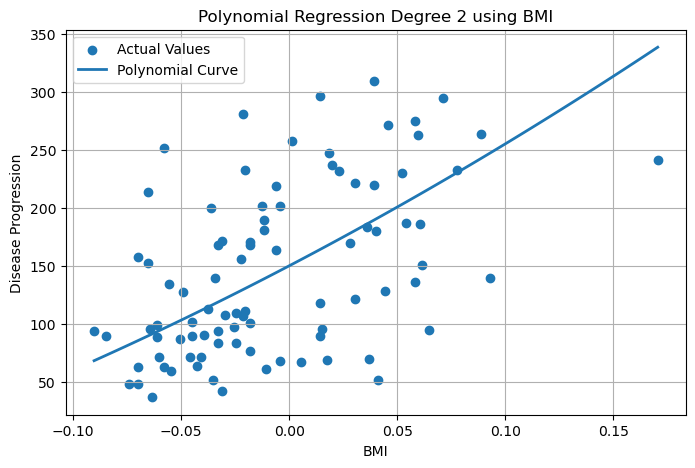

In [32]:
#Visualize Polynomial Regression

X_range = np.linspace(
    X_simple.min().values[0],
    X_simple.max().values[0],
    100
).reshape(-1, 1)

y_range_pred = poly_model.predict(X_range)

plt.figure(figsize=(8, 5))
plt.scatter(X_test_simple, y_test_simple, label="Actual Values")
plt.plot(X_range, y_range_pred, linewidth=2, label="Polynomial Curve")
plt.title("Polynomial Regression Degree 2 using BMI")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.legend()
plt.grid(True)
plt.show()


In [33]:
# Ridge Regression

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_test,
    y_test
)


Ridge Regression
MAE: 42.812
MSE: 2892.0146
RMSE: 53.7775
R2 Score: 0.4541


In [34]:
#Lasso Regression

# Lasso Regression applies L1 regularization.
# It can shrink some coefficients close to zero and helps with feature selection.

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_test,
    y_test
)

Lasso Regression
MAE: 42.8052
MSE: 2884.6243
RMSE: 53.7087
R2 Score: 0.4555


In [35]:
#Compare All Model Results

results_df = pd.DataFrame(results)

results_df


,Model,MAE,MSE,RMSE,R2 Score
0,Simple Linear Regression using BMI,52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear Regression,42.794095,2900.193628,53.853446,0.452603
2,Polynomial Regression Degree 2 using BMI,52.383912,4085.025481,63.914204,0.228972
3,Ridge Regression,42.811999,2892.014566,53.777454,0.454147
4,Lasso Regression,42.805234,2884.624289,53.708698,0.455541


In [36]:
#Sort Models Based on RMSE

results_df_sorted = results_df.sort_values(by="RMSE")

results_df_sorted

,Model,MAE,MSE,RMSE,R2 Score
4,Lasso Regression,42.805234,2884.624289,53.708698,0.455541
3,Ridge Regression,42.811999,2892.014566,53.777454,0.454147
1,Multiple Linear Regression,42.794095,2900.193628,53.853446,0.452603
0,Simple Linear Regression using BMI,52.259976,4061.825928,63.732456,0.233350
2,Polynomial Regression Degree 2 using BMI,52.383912,4085.025481,63.914204,0.228972


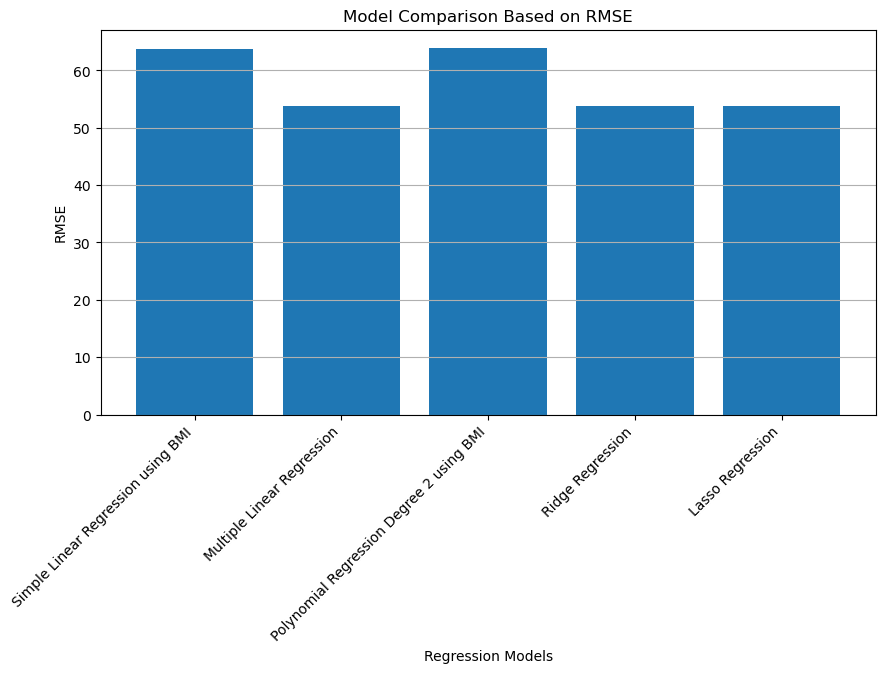

In [37]:
#Visualize Model Comparison Using RMSE

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


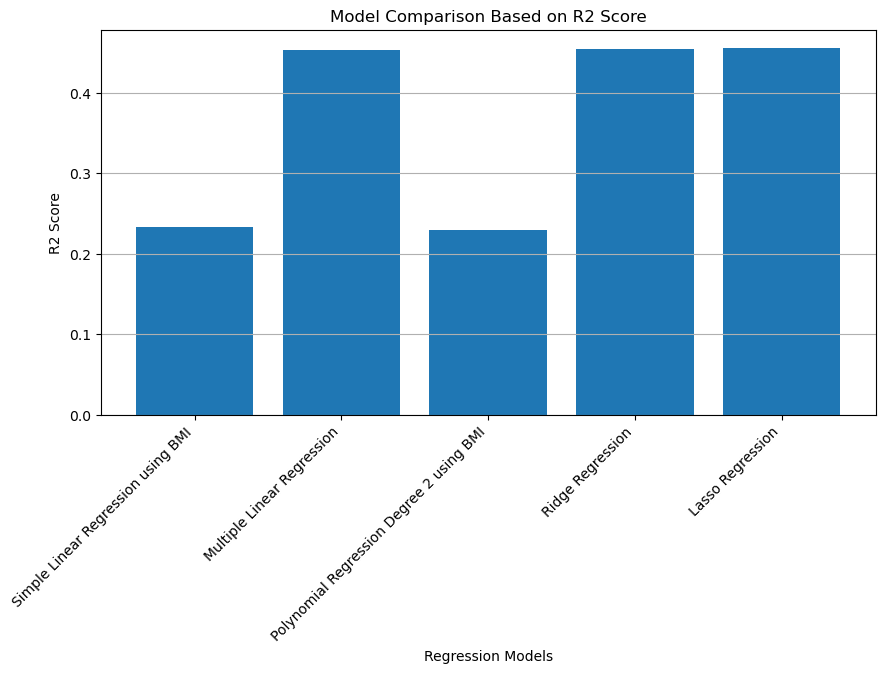

In [38]:
# Visualize Model Comparison Using R2 Score

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Regression Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()


In [39]:
#Compare Actual and Predicted Values

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Simple Linear Regression": y_pred_simple,
    "Multiple Linear Regression": y_pred_multiple,
    "Polynomial Regression": y_pred_poly,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso
})

comparison_df.head(10)

,Actual,Simple Linear Regression,Multiple Linear Regression,Polynomial Regression,Ridge Regression,Lasso Regression
0,219.0,145.806227,139.547558,144.316524,139.862774,140.228730
1,70.0,188.857390,179.517208,187.378539,179.958241,180.323488
2,202.0,147.958785,134.038756,146.402244,135.716875,137.014955
3,230.0,203.925298,291.417029,203.120506,292.115782,291.371840
4,111.0,131.814599,123.789659,130.932229,123.189315,122.814887
5,84.0,127.509482,92.172347,126.874273,92.634210,92.630951
6,242.0,322.315998,258.232389,338.900457,257.855409,257.890488
7,272.0,197.467623,181.337321,196.331392,182.984376,184.449698
8,94.0,61.856458,90.224113,68.505759,88.571103,88.027583
9,96.0,167.331809,108.633759,165.492896,109.341302,109.991801


In [40]:
#Compare Ridge and Lasso Coefficients

ridge_coefficients = ridge_model.named_steps["ridge"].coef_
lasso_coefficients = lasso_model.named_steps["lasso"].coef_

regularization_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_coefficients,
    "Lasso Coefficient": lasso_coefficients
})

regularization_coefficients

,Feature,Ridge Coefficient,Lasso Coefficient
0,age,1.807342,1.730451
1,sex,-11.448190,-11.316359
2,bmi,25.732699,25.824627
3,bp,16.734300,16.644252
4,s1,-34.671954,-29.358412
5,s2,17.053075,13.275844
6,s3,3.369914,0.547948
7,s4,11.764260,10.236168
8,s5,31.378384,29.632826
9,s6,2.458139,2.393475


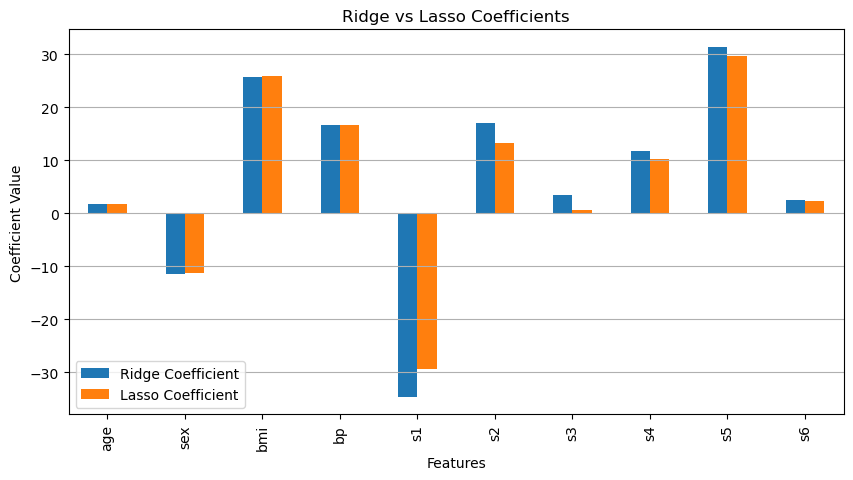

In [41]:
#Visualize Ridge and Lasso Coefficients

regularization_coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ridge vs Lasso Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.grid(axis="y")
plt.show()